# Gaia DR3 XP Debug Notebook

Standalone debug notebook for Gaia DR3 sampled XP spectra.

Source: `4376052292820097920`

This notebook does not use the TOM data-service code path. It queries ESA and AIP directly, inspects the returned table shape, normalizes the spectrum, and plots it.

In [1]:
from astropy.table import Table
from astroquery.gaia import Gaia
import matplotlib.pyplot as plt
import numpy as np
import pyvo

SOURCE_ID = 4376052292820097920
AIP_TAP_URL = 'https://gaia.aip.de/tap'
GAIA_XP_WAVELENGTH_NM = [336.0 + 2.0 * idx for idx in range(343)]

plt.rcParams['figure.figsize'] = (12, 5)

Some IP addresses of users launching heavy query showers have temporarily been disabled. Please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk) for advice. Workaround solutions for the Gaia Archive issues following the infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [2]:
def value_to_python(value):
    mask = getattr(value, 'mask', None)
    if mask is not None:
        if hasattr(mask, 'all'):
            if mask.all():
                return None
        elif bool(mask):
            return None

    if hasattr(value, 'filled') and hasattr(mask, 'all'):
        filled = value.filled(None)
        if hasattr(filled, 'tolist'):
            return filled.tolist()
        return filled

    if hasattr(value, 'tolist'):
        return value.tolist()
    return value.item() if hasattr(value, 'item') else value


def row_to_dict(row):
    return {key: value_to_python(row[key]) for key in row.colnames}


def ensure_sequence(value):
    if value is None:
        return []
    if isinstance(value, (list, tuple)):
        return list(value)
    if hasattr(value, 'tolist'):
        converted = value.tolist()
        return converted if isinstance(converted, list) else [converted]
    return [value]


def normalize_spectrum_table(table):
    if len(table) == 0:
        return None

    first_row = row_to_dict(table[0])
    row_keys = {key.lower(): key for key in first_row.keys()}

    if {'wavelength', 'flux'} <= set(row_keys):
        wavelengths = []
        fluxes = []
        flux_errors = []
        for row in table:
            row_data = row_to_dict(row)
            wavelength = row_data.get(row_keys['wavelength'])
            flux = row_data.get(row_keys['flux'])
            flux_error = row_data.get(row_keys.get('flux_error'))
            if wavelength is None or flux is None:
                continue
            wavelengths.append(float(wavelength))
            fluxes.append(float(flux))
            flux_errors.append(None if flux_error is None else float(flux_error))
        return {
            'wavelength': wavelengths,
            'wavelength_units': 'nm',
            'flux': fluxes,
            'flux_units': 'W / (nm m2)',
            'flux_error': flux_errors,
            'flux_error_units': 'W / (nm m2)',
        }

    flux = ensure_sequence(first_row.get(row_keys.get('flux', 'flux')))
    flux_error = ensure_sequence(first_row.get(row_keys.get('flux_error', 'flux_error')))
    if flux:
        return {
            'wavelength': list(GAIA_XP_WAVELENGTH_NM),
            'wavelength_units': 'nm',
            'flux': [float(val) for val in flux],
            'flux_units': 'W / (nm m2)',
            'flux_error': [None if val is None else float(val) for val in flux_error],
            'flux_error_units': 'W / (nm m2)',
        }

    return None


def summarize_table(table, label):
    print(f'[{label}] rows={len(table)} columns={table.colnames}')
    if len(table):
        preview = row_to_dict(table[0])
        for key, value in preview.items():
            if isinstance(value, list):
                print(f'  {key}: list(len={len(value)})')
            else:
                print(f'  {key}: {value}')

In [3]:
source_query = f'''
SELECT source_id, ra, dec, has_xp_sampled
FROM gaiadr3.gaia_source
WHERE source_id = {SOURCE_ID}
'''

esa_source = Gaia.launch_job(source_query).get_results()
print('ESA source rows:', len(esa_source))
if len(esa_source):
    print(row_to_dict(esa_source[0]))

aip_source = pyvo.dal.TAPService(AIP_TAP_URL).run_sync(source_query, language='ADQL').to_table()
print('AIP source rows:', len(aip_source))
if len(aip_source):
    print(row_to_dict(aip_source[0]))

ESA source rows: 1
{'source_id': 4376052292820097920, 'ra': 266.04719071884324, 'dec': 2.5032498365541094, 'has_xp_sampled': True}
AIP source rows: 1
{'source_id': 4376052292820097920, 'ra': 266.04719071884324, 'dec': 2.5032498365541094, 'has_xp_sampled': True}


In [4]:
esa_datalink = Gaia.load_data(
    ids=[str(SOURCE_ID)],
    data_release='Gaia DR3',
    retrieval_type='XP_SAMPLED',
    data_structure='INDIVIDUAL',
    verbose=False,
    format='votable',
)

print('ESA datalink keys:', sorted(esa_datalink.keys()))
esa_tables = []
for key in sorted(esa_datalink.keys()):
    for table_obj in esa_datalink[key]:
        table = table_obj.to_table() if hasattr(table_obj, 'to_table') else table_obj
        summarize_table(table, f'ESA {key}')
        esa_tables.append(table)

esa_spectrum = None
for table in esa_tables:
    esa_spectrum = normalize_spectrum_table(table)
    if esa_spectrum:
        break

print('ESA normalized spectrum points:', 0 if esa_spectrum is None else len(esa_spectrum['flux']))

ESA datalink keys: ['XP_SAMPLED-Gaia DR3 4376052292820097920.xml']
[ESA XP_SAMPLED-Gaia DR3 4376052292820097920.xml] rows=343 columns=['wavelength', 'flux', 'flux_error']
  wavelength: 336.0
  flux: 4.3941134466739763e-17
  flux_error: 3.947698959330133e-17
ESA normalized spectrum points: 343


In [5]:
aip_query = f'''
SELECT source_id, flux, flux_error
FROM gaiadr3.xp_sampled_mean_spectrum
WHERE source_id = {SOURCE_ID}
'''

aip_table = pyvo.dal.TAPService(AIP_TAP_URL).run_sync(aip_query, language='ADQL').to_table()
summarize_table(aip_table, 'AIP xp_sampled_mean_spectrum')
aip_spectrum = normalize_spectrum_table(aip_table)
print('AIP normalized spectrum points:', 0 if aip_spectrum is None else len(aip_spectrum['flux']))

[AIP xp_sampled_mean_spectrum] rows=1 columns=['source_id', 'flux', 'flux_error']
  source_id: 4376052292820097920
  flux: list(len=343)
  flux_error: list(len=343)
AIP normalized spectrum points: 343


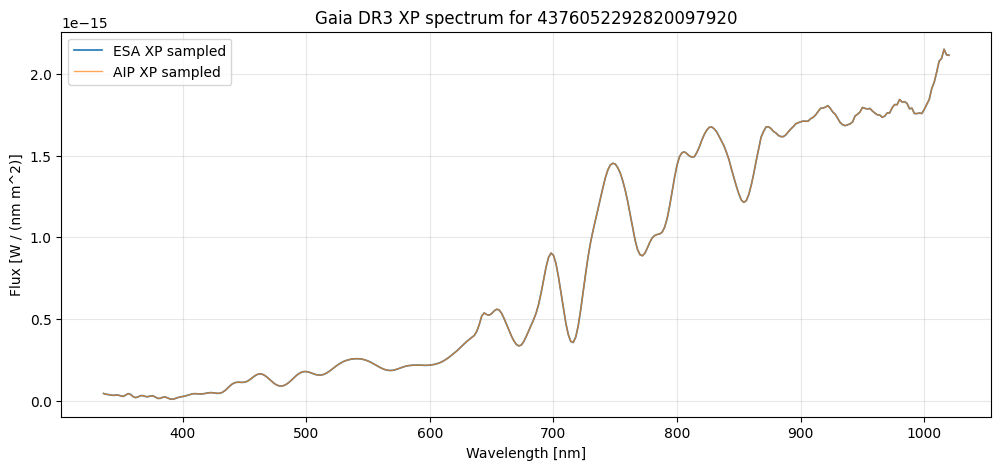

In [6]:
fig, ax = plt.subplots()

if esa_spectrum:
    ax.plot(esa_spectrum['wavelength'], esa_spectrum['flux'], label='ESA XP sampled', lw=1.2)

if aip_spectrum:
    ax.plot(aip_spectrum['wavelength'], aip_spectrum['flux'], label='AIP XP sampled', lw=1.0, alpha=0.7)

ax.set_title(f'Gaia DR3 XP spectrum for {SOURCE_ID}')
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Flux [W / (nm m^2)]')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()